Student Names: Morad Zubidat 208156828

# NavSight VIO vs GPS — Simulation Data Analysis

## Project Overview

The objective of this analysis is to evaluate the accuracy of NavSight's Visual-Inertial Odometry (VIO) system by comparing its position estimates against GPS ground truth data. We analyze four simulation recordings — two from an earlier version of the code (basic schema) and two from the improved version (extended schema with diagnostic fields). For each simulation, we compute accuracy metrics, visualize trajectories, and identify what code improvements led to better results.

## Description of the Dataset

The dataset consists of JSON recordings captured by the NavSight Android app during real-world walking and driving sessions. Each recording contains timestamped VIO position estimates and GPS coordinates collected simultaneously.

**Two schemas exist:**
- **Basic (old code):** VIO position (vx, vy, vz), yaw, scale, quality, GPS (lat, lng, alt, accuracy)
- **Extended (new code):** All basic fields + accelerometer, gyroscope, optical flow, step detection, heading, inlier count, processing flags

**Location:** Yokne'am Illit area, Israel (~32.73N, 35.14E)

### Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import math
import glob
from pathlib import Path
from matplotlib.patches import Patch

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

### Helper Functions

In [2]:
def haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) ** 2 +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) ** 2)
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def gps_to_local_meters(lats, lons, ref_lat, ref_lon):
    xs, ys = [], []
    for lat, lon in zip(lats, lons):
        dy = haversine_m(ref_lat, ref_lon, lat, ref_lon)
        if lat < ref_lat: dy = -dy
        dx = haversine_m(ref_lat, ref_lon, ref_lat, lon)
        if lon < ref_lon: dx = -dx
        xs.append(dx); ys.append(dy)
    return np.array(xs), np.array(ys)

### Load the simulation data

In [3]:
sim_candidates = [Path(".") / "simulator", Path("..") / "simulator",
                  Path("C:/Users/morad/AndroidStudioProjects/NavSight1/simulator")]
sim_dir = next((d for d in sim_candidates if d.exists()), None)
json_files = sorted(glob.glob(str(sim_dir / "simulation_data_*.json")))
print(f"Found {len(json_files)} simulation files in {sim_dir}")

simulations = []
for fp in json_files:
    with open(fp) as f:
        raw = json.load(f)
    df = pd.DataFrame(raw["points"])
    t0 = df["ts"].iloc[0]
    df["time_s"] = (df["ts"] - t0) / 1000
    has_ext = "steps" in df.columns
    schema = "Extended" if has_ext else "Basic"
    gps = df.dropna(subset=["glat", "glng"])
    gps_total = sum(haversine_m(gps["glat"].iloc[i], gps["glng"].iloc[i],
                                gps["glat"].iloc[i+1], gps["glng"].iloc[i+1])
                    for i in range(len(gps)-1)) if len(gps) >= 2 else 0
    duration = float(df["time_s"].iloc[-1])
    gps_speed = (gps_total / duration * 3.6) if duration > 0 else 0
    mode = "Driving" if gps_speed > 8 else "Walking"
    simulations.append({"name": Path(fp).stem.replace("simulation_data_", ""),
        "df": df, "schema": schema, "mode": mode,
        "gps_total_m": gps_total, "duration_s": duration,
        "gps_speed_kmh": gps_speed, "has_ext": has_ext})
print(f"Loaded {len(simulations)} simulations.")

Found 4 simulation files in ..\simulator
Loaded 4 simulations.


### Retrieve the first five rows of the data

In [4]:
simulations[-1]["df"].head()

,ts,vx,vy,vz,vyaw,vsc,vql,rx,ry,rz,...,galt,gacc,mflow,inl,steps,sfreq,stride,pflags,hdg,time_s
0,1774948250922,0.003712,-0.168474,-0.199966,0.007664,1.0,0.993737,0.952529,-0.304435,-0.002704,...,NaN,NaN,1.993481,0,1,0.0,0.65,8,0.007664,0.000
1,1774948251373,0.003712,-0.168474,-0.199966,0.003031,1.0,0.997899,0.009444,-0.084749,0.996358,...,NaN,NaN,2.902287,0,1,0.0,0.65,8,0.003031,0.451
2,1774948251942,0.003712,-0.168474,-0.199966,-0.003908,1.0,0.997895,0.061449,-0.005558,0.998095,...,NaN,NaN,6.411649,0,1,0.0,0.65,8,-0.003908,1.020
3,1774948252406,0.003712,-0.168474,-0.199966,-0.016862,1.0,0.997890,-0.046862,0.349480,-0.935771,...,NaN,NaN,7.019824,1,1,0.0,0.65,8,-0.016862,1.484
4,1774948253214,0.003712,-0.168474,-0.199966,-0.031740,0.2,0.033827,0.950072,-0.158679,-0.268670,...,229.800003,20.4,123.831855,9,1,0.0,0.65,12,-0.031740,2.292


In [5]:
simulations[-1]["df"].shape

(106, 29)

### Check statistics of the numerical features

In [6]:
simulations[-1]["df"].describe()

,ts,vx,vy,vz,vyaw,vsc,vql,rx,ry,rz,...,galt,gacc,mflow,inl,steps,sfreq,stride,pflags,hdg,time_s
count,1.060000e+02,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,...,102.000000,102.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000
mean,1.774948e+12,0.708698,-0.548331,-4.641451,0.527727,0.694589,0.346188,0.201694,-0.034780,-0.082662,...,229.800003,23.642824,41.784232,94.301887,30.877358,1.427763,0.856631,7.433962,0.527727,24.432415
std,1.446140e+04,0.658020,0.147686,5.409884,2.159521,0.386492,0.410269,0.563017,0.273995,0.673788,...,0.000000,26.537580,30.267792,162.733973,20.574928,0.540857,0.090475,2.433962,2.159521,14.461400
min,1.774948e+12,-0.196431,-0.884987,-14.570008,-3.129651,0.200000,0.004124,-0.983477,-0.875730,-0.990988,...,229.800003,4.000000,1.993481,0.000000,1.000000,0.000000,0.630769,4.000000,-3.129651,0.000000
25%,1.774948e+12,0.073666,-0.596728,-8.788648,-0.065904,0.200000,0.033925,-0.209180,-0.160416,-0.793398,...,229.800003,5.715000,24.219921,4.250000,11.000000,1.515143,0.854543,4.000000,-0.065904,10.773000
50%,1.774948e+12,0.913339,-0.596728,-4.258058,0.025481,1.000000,0.089090,0.015588,-0.005227,-0.141339,...,229.800003,9.079000,29.490063,9.000000,31.000000,1.587287,0.876186,8.000000,0.025481,26.094500
75%,1.774948e+12,1.280106,-0.520184,-0.399653,2.972018,1.000000,0.917829,0.872025,0.048633,0.479557,...,229.800003,20.400000,53.516749,84.500000,49.750000,1.666682,0.900005,8.000000,2.972018,37.646500
max,1.774948e+12,1.849381,-0.168474,5.329900,3.124300,1.000000,1.000000,0.998535,0.942288,0.998095,...,229.800003,86.536000,157.499614,537.000000,61.000000,1.999980,0.999994,12.000000,3.124300,45.102000


### Check for missing values

In [7]:
for sim in simulations:
    nulls = sim["df"][["glat", "glng"]].isnull().sum()
    total = len(sim["df"])
    gps_pct = (1 - nulls["glat"] / total) * 100
    print(f'{sim["name"]} ({sim["mode"]}): {total} frames, GPS in {gps_pct:.0f}% of frames')

1774884232152 (Walking): 134 frames, GPS in 94% of frames
1774885901757 (Walking): 119 frames, GPS in 92% of frames
1774948005588 (Driving): 86 frames, GPS in 97% of frames
1774948296267 (Walking): 106 frames, GPS in 96% of frames


---

## Compute Accuracy Metrics

For each simulation we compute:
- **GPS total path** — sum of haversine distances between consecutive GPS points
- **VIO total path** — sum of Euclidean distances between consecutive VIO positions
- **Distance ratio (VIO/GPS)** — ideal value is 1.0
- **Straight-line drift error** — difference between VIO and GPS endpoint distances
- **Accuracy (%)** — 100% minus drift percentage, clamped to [0, 100]

In [8]:
results = []
for sim in simulations:
    df = sim["df"]
    vio_dx = df["vx"].diff(); vio_dz = df["vz"].diff()
    vio_total = float(np.sqrt(vio_dx**2 + vio_dz**2).sum())
    vio_straight = float(np.sqrt(df["vx"].iloc[-1]**2 + df["vz"].iloc[-1]**2))
    gps = df.dropna(subset=["glat", "glng"])
    gps_total = sim["gps_total_m"]
    gps_straight = haversine_m(gps["glat"].iloc[0], gps["glng"].iloc[0],
                               gps["glat"].iloc[-1], gps["glng"].iloc[-1]) if len(gps) >= 2 else 0
    dist_ratio = vio_total / gps_total if gps_total > 0 else 0
    drift_error = abs(vio_straight - gps_straight)
    drift_pct = (drift_error / gps_straight * 100) if gps_straight > 0 else 0
    accuracy = max(0, min(100, 100 - drift_pct))
    dts = df["ts"].diff().dropna() / 1000
    avg_fps = 1 / dts.mean() if dts.mean() > 0 else 0
    sim.update({"vio_total_m": vio_total, "vio_straight_m": vio_straight,
        "gps_straight_m": gps_straight, "dist_ratio": dist_ratio,
        "drift_error_m": drift_error, "drift_pct": drift_pct,
        "accuracy": accuracy, "avg_fps": avg_fps, "avg_quality": float(df["vql"].mean())})
    results.append({"Simulation": sim["name"], "Mode": sim["mode"], "Schema": sim["schema"],
        "Duration (s)": f'{sim["duration_s"]:.1f}', "FPS": f"{avg_fps:.1f}",
        "GPS Path (m)": f"{gps_total:.1f}", "VIO Path (m)": f"{vio_total:.1f}",
        "VIO/GPS": f"{dist_ratio:.3f}", "Drift (m)": f"{drift_error:.1f}",
        "Drift (%)": f"{drift_pct:.1f}%", "Accuracy (%)": f"{accuracy:.1f}%"})
pd.DataFrame(results)

,Simulation,Mode,Schema,Duration (s),FPS,GPS Path (m),VIO Path (m),VIO/GPS,Drift (m),Drift (%),Accuracy (%)
0,1774884232152,Walking,Basic,44.6,3.0,48.4,1.5,0.031,5.6,91.2%,8.8%
1,1774885901757,Walking,Basic,43.0,2.7,44.5,46.1,1.037,38.8,958.1%,0.0%
2,1774948005588,Driving,Extended,37.0,2.3,104.9,26.3,0.251,0.4,11.2%,88.8%
3,1774948296267,Walking,Extended,45.1,2.3,49.1,35.4,0.720,0.2,3.0%,97.0%


### Accuracy per Simulation

#### What this chart shows

This bar chart displays the **VIO accuracy percentage** for each simulation session. Accuracy is computed as `100% - drift%`, where drift is the difference between VIO and GPS straight-line endpoint distances divided by the GPS distance.

- **Green bars** (>80%): Good accuracy — VIO closely matches GPS ground truth.
- **Orange bars** (50-80%): Acceptable but with noticeable drift.
- **Red bars** (<50%): Poor accuracy — the VIO system drifted significantly from the real path.

The dashed lines mark the 80% (good) and 50% (acceptable) thresholds.

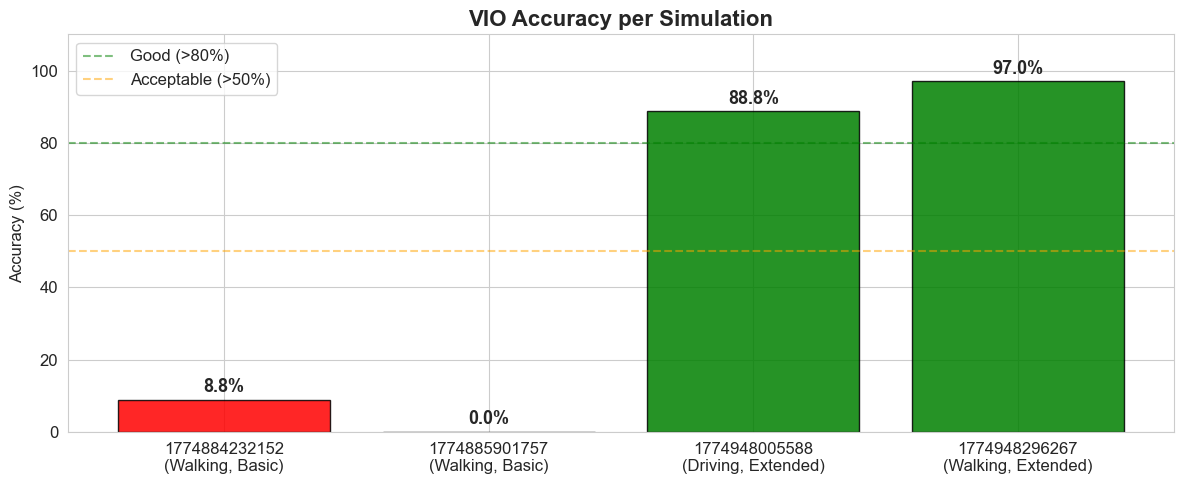

In [9]:
names = [f'{s["name"]}\n({s["mode"]}, {s["schema"]})' for s in simulations]
accuracies = [s["accuracy"] for s in simulations]
colors = ["green" if a > 80 else "orange" if a > 50 else "red" for a in accuracies]

plt.figure(figsize=(12, 5))
bars = plt.bar(names, accuracies, color=colors, edgecolor="black", alpha=0.85)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=13)
plt.axhline(y=80, color="green", linestyle="--", alpha=0.5, label="Good (>80%)")
plt.axhline(y=50, color="orange", linestyle="--", alpha=0.5, label="Acceptable (>50%)")
plt.title("VIO Accuracy per Simulation", fontsize=16, fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.legend()
plt.tight_layout()
plt.show()

### Accuracy Improvement Between Simulations

We compare each simulation to the previous one to measure accuracy improvement.
Simulations 1-2 used the **basic (old) code**, while 3-4 used the **extended (new) code** with all VIO fixes.

In [10]:
improvement_data = []
for i, sim in enumerate(simulations):
    delta = sim["accuracy"] - simulations[i-1]["accuracy"] if i > 0 else 0
    note = "Baseline" if i == 0 else f'vs {simulations[i-1]["name"]}'
    improvement_data.append({"Simulation": sim["name"], "Mode": sim["mode"],
        "Code Version": sim["schema"], "Accuracy (%)": f'{sim["accuracy"]:.1f}%',
        "Change": f'{"+" if delta >= 0 else ""}{delta:.1f}%', "Note": note})
pd.DataFrame(improvement_data)

,Simulation,Mode,Code Version,Accuracy (%),Change,Note
0,1774884232152,Walking,Basic,8.8%,+0.0%,Baseline
1,1774885901757,Walking,Basic,0.0%,-8.8%,vs 1774884232152
2,1774948005588,Driving,Extended,88.8%,+88.8%,vs 1774885901757
3,1774948296267,Walking,Extended,97.0%,+8.3%,vs 1774948005588


#### What this chart shows

This trend chart tracks **how accuracy evolved** across simulations in chronological order. Each point is one simulation session, connected by a line to show the progression.

- **Gray background bars** = simulations run on the old (basic) code.
- **Blue background bars** = simulations run on the new (extended) code with VIO fixes.
- The **percentage annotations** show both absolute accuracy and the delta (change) from the previous simulation.

A large jump between basic and extended code versions confirms that the VIO fixes had a significant positive impact.

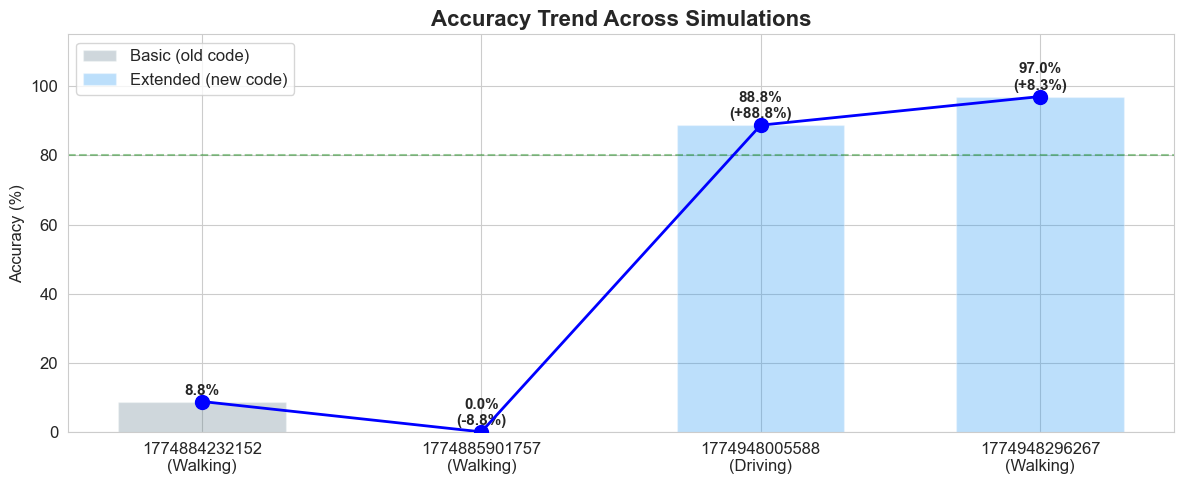

In [11]:
# Accuracy trend chart
plt.figure(figsize=(12, 5))
x = range(len(simulations))
accs = [s["accuracy"] for s in simulations]
schema_colors = ["#607D8B" if s["schema"] == "Basic" else "#2196F3" for s in simulations]

plt.plot(x, accs, "o-", color="blue", linewidth=2, markersize=10, zorder=5)
for i, (acc, sc) in enumerate(zip(accs, schema_colors)):
    plt.bar(i, acc, color=sc, alpha=0.3, width=0.6)
    label = f"{acc:.1f}%"
    if i > 0:
        delta = acc - accs[i-1]
        label += f'\n({"+" if delta >= 0 else ""}{delta:.1f}%)'
    plt.text(i, acc + 2, label, ha="center", fontsize=11, fontweight="bold")

plt.xticks(x, [f'{s["name"]}\n({s["mode"]})' for s in simulations])
plt.axhline(y=80, color="green", linestyle="--", alpha=0.4)
plt.title("Accuracy Trend Across Simulations", fontsize=16, fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 115)
plt.legend(handles=[Patch(facecolor="#607D8B", alpha=0.3, label="Basic (old code)"),
                     Patch(facecolor="#2196F3", alpha=0.3, label="Extended (new code)")])
plt.tight_layout()
plt.show()

### Average accuracy by code version

#### What this chart shows

A simple comparison of the **average accuracy** across the two code versions:

- **Basic (old code):** Original VIO implementation with known issues (gravity-based heading, accelerometer double-integration for scale, etc.)
- **Extended (new code):** Improved VIO with 2D heading, step-based scale, driving mode detection, and relaxed thresholds.

The height difference between the two bars directly quantifies the improvement achieved by the code changes.

Basic (old code) average accuracy:    4.4%
Extended (new code) average accuracy:  92.9%
Improvement:                           +88.5%



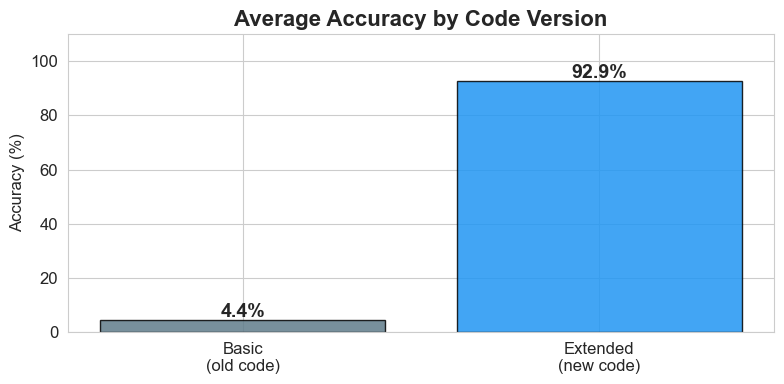

In [12]:
basic_acc = np.mean([s["accuracy"] for s in simulations if s["schema"] == "Basic"])
ext_acc = np.mean([s["accuracy"] for s in simulations if s["schema"] == "Extended"])
improvement = ext_acc - basic_acc
print(f"Basic (old code) average accuracy:    {basic_acc:.1f}%")
print(f"Extended (new code) average accuracy:  {ext_acc:.1f}%")
print(f'Improvement:                           {"+" if improvement >= 0 else ""}{improvement:.1f}%')
print()
plt.figure(figsize=(8, 4))
bars = plt.bar(["Basic\n(old code)", "Extended\n(new code)"],
               [basic_acc, ext_acc], color=["#607D8B", "#2196F3"], edgecolor="black", alpha=0.85)
for bar, acc in zip(bars, [basic_acc, ext_acc]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.1f}%", ha="center", fontweight="bold", fontsize=14)
plt.title("Average Accuracy by Code Version", fontsize=16, fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

---

## Per-Simulation Detailed Analysis

For each simulation we show trajectory comparison, distance over time, tracking quality, heading, and extended diagnostics (optical flow, step detection, accelerometer) where available.

### Understanding the per-simulation charts

For each simulation, up to 5 chart rows are generated:

1. **Trajectory (left)** — Bird's-eye view comparing VIO path (blue) vs GPS path (red) in local meters. The green star marks the starting point. Ideally both paths overlap.

2. **Distance from Origin (right)** — How far VIO and GPS are from the start over time. If the lines diverge, VIO is drifting. A close match means good scale estimation.

3. **Tracking Quality (left)** — VIO confidence score (0 to 1) over time. Values below the red dashed line (0.15) mean the tracker lost features and the frame was rejected.

4. **Heading (right)** — Direction the user is facing. VIO yaw (purple) should follow a smooth path. The cyan dashed line (2D heading) shows the corrected heading used in the new code.

5. **Extended diagnostics** (new code only):
   - **Optical Flow:** Average pixel displacement between frames. Below 0.4px = camera is nearly stationary.
   - **Inliers:** Number of feature matches surviving RANSAC. Below 8 = unreliable pose estimate.
   - **Step Detection:** Cumulative step count (black) and step frequency in Hz (red). Used for scale estimation.
   - **Accelerometer:** Raw accelerometer magnitude. Peaks above/below gravity (9.81) indicate footsteps.
   - **Stride Length:** Estimated distance per step (meters). Healthy walking is 0.5-0.8m.
   - **Scale Factor:** VIO-to-real-world scaling. Should converge to a stable value; erratic changes indicate poor estimation.


  SIMULATION 1: 1774884232152
  Mode: Walking | Schema: Basic | Duration: 44.6s | FPS: 3.0
  Accuracy: 8.8% | Drift: 5.6m (91.2%)


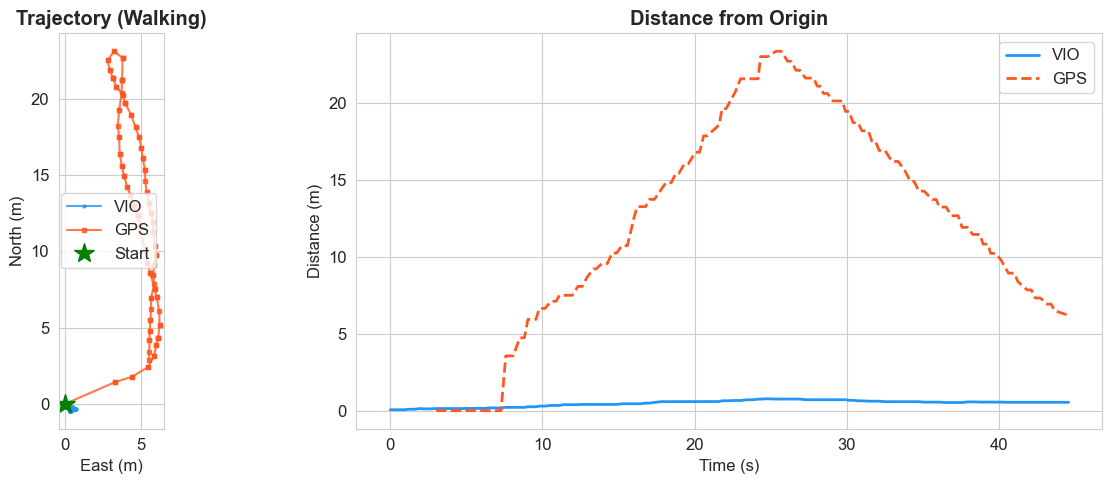

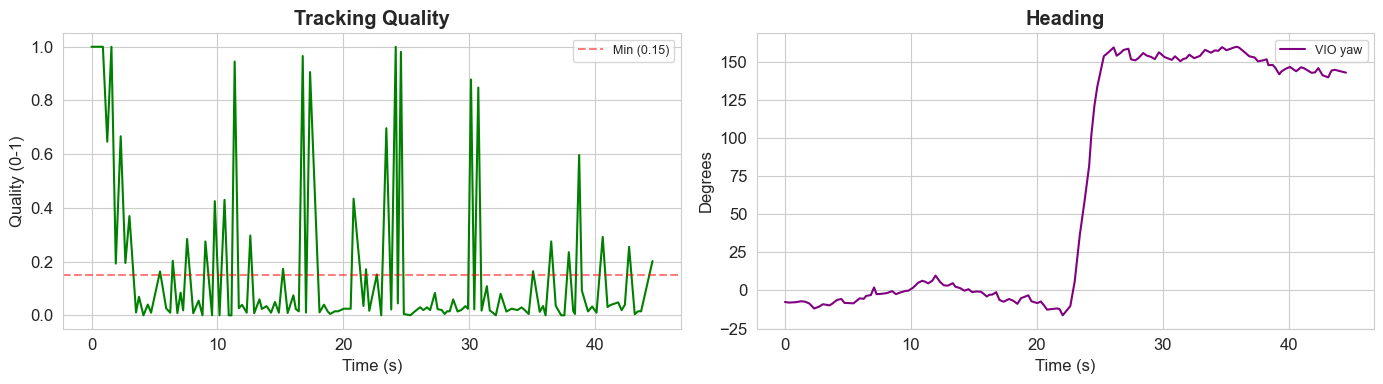


  SIMULATION 2: 1774885901757
  Mode: Walking | Schema: Basic | Duration: 43.0s | FPS: 2.7
  Accuracy: 0.0% | Drift: 38.8m (958.1%)


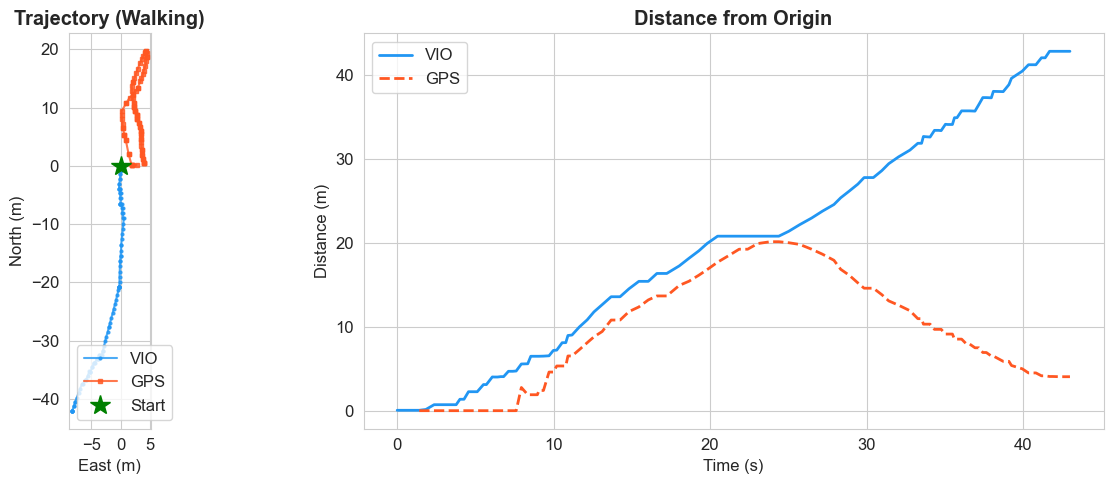

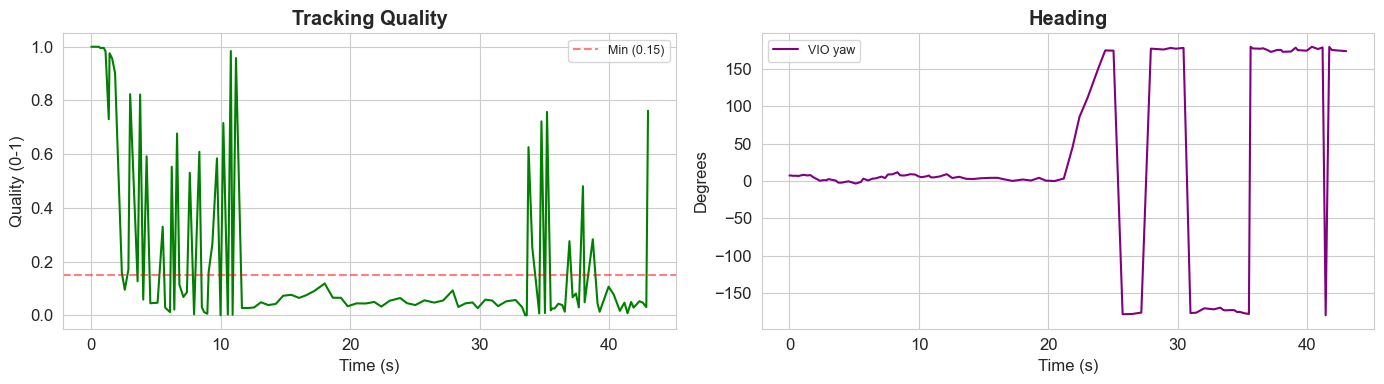


  SIMULATION 3: 1774948005588
  Mode: Driving | Schema: Extended | Duration: 37.0s | FPS: 2.3
  Accuracy: 88.8% | Drift: 0.4m (11.2%)


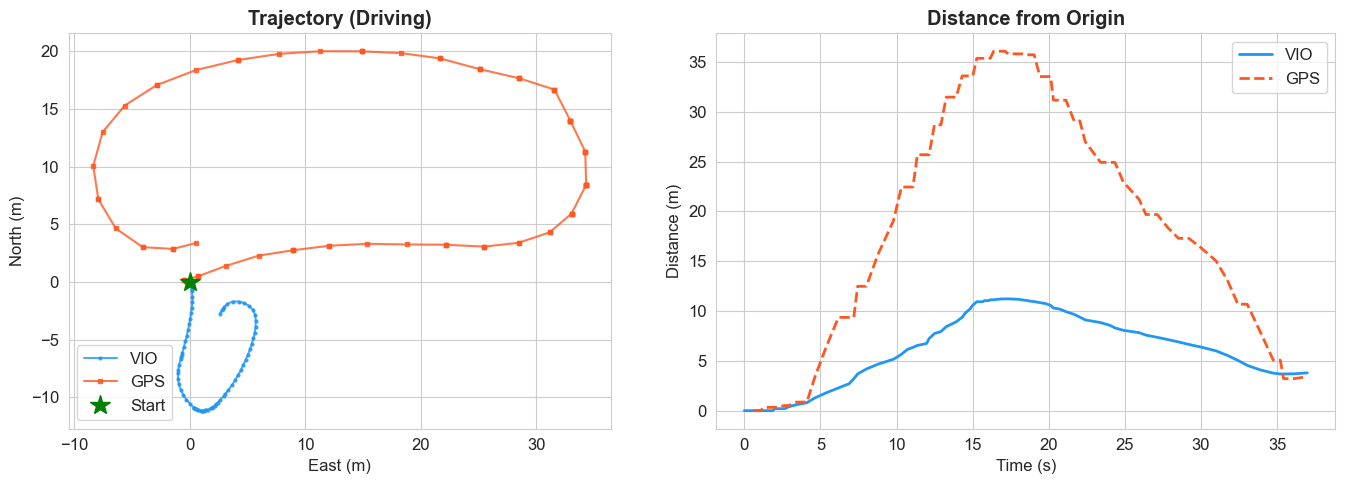

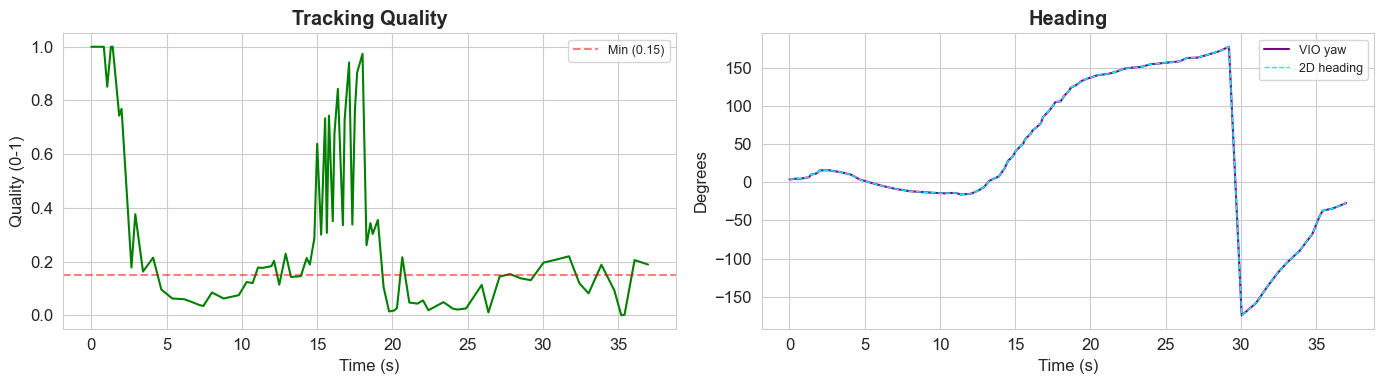

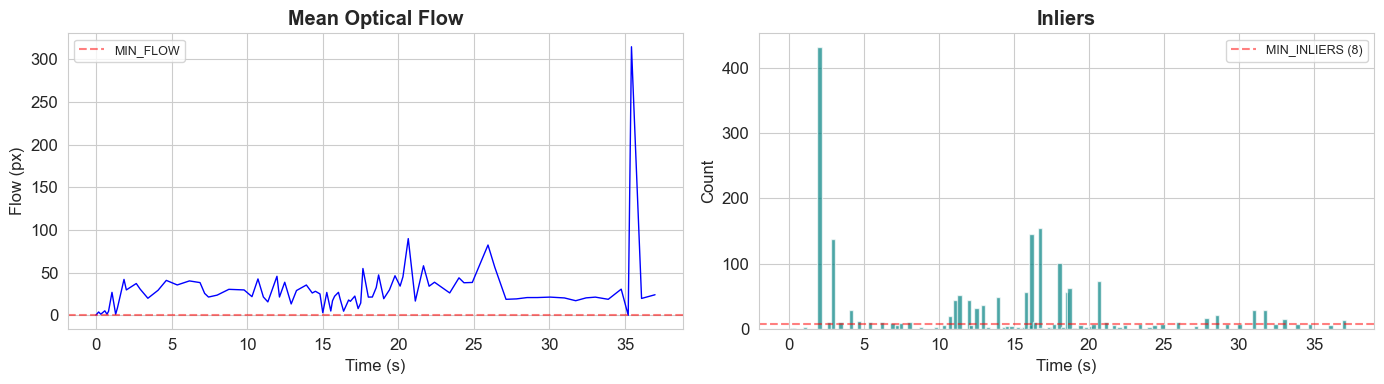

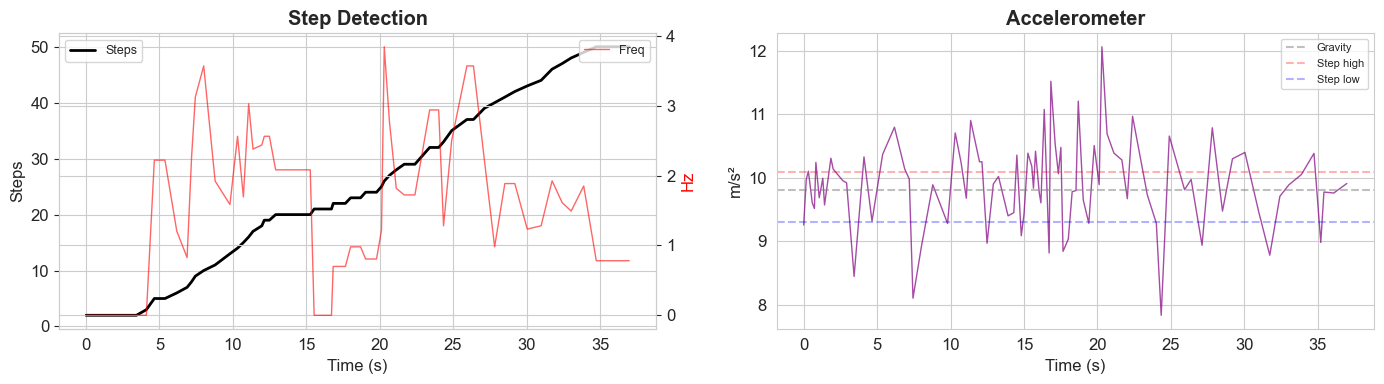

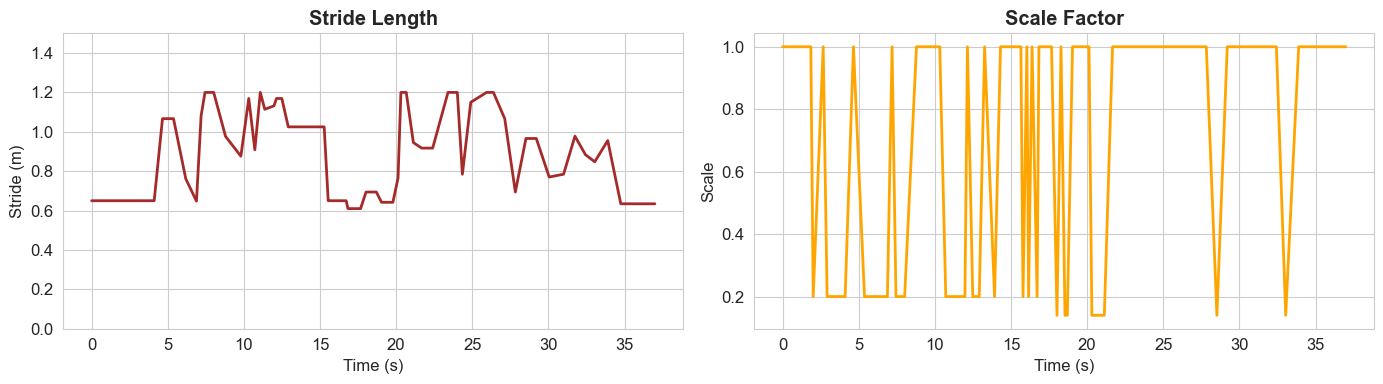


  SIMULATION 4: 1774948296267
  Mode: Walking | Schema: Extended | Duration: 45.1s | FPS: 2.3
  Accuracy: 97.0% | Drift: 0.2m (3.0%)


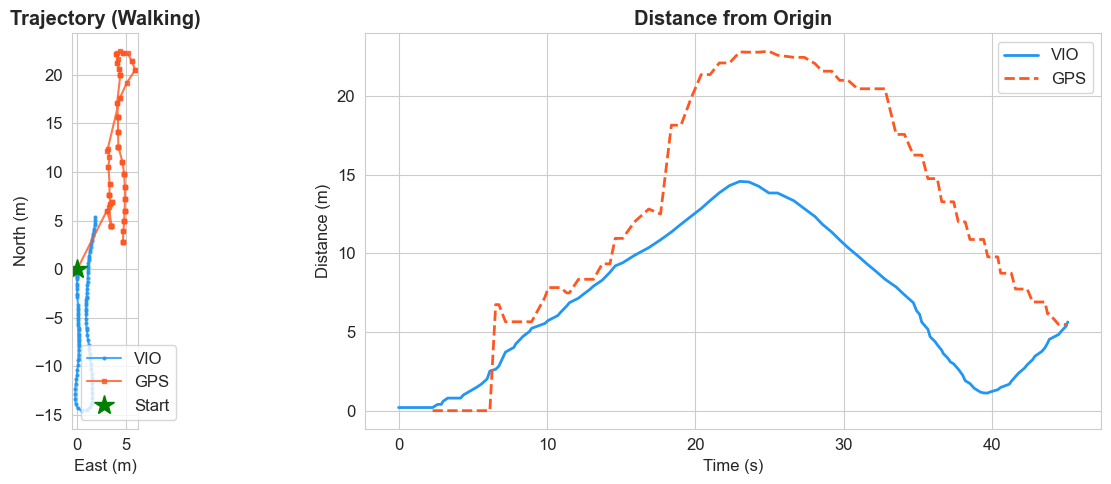

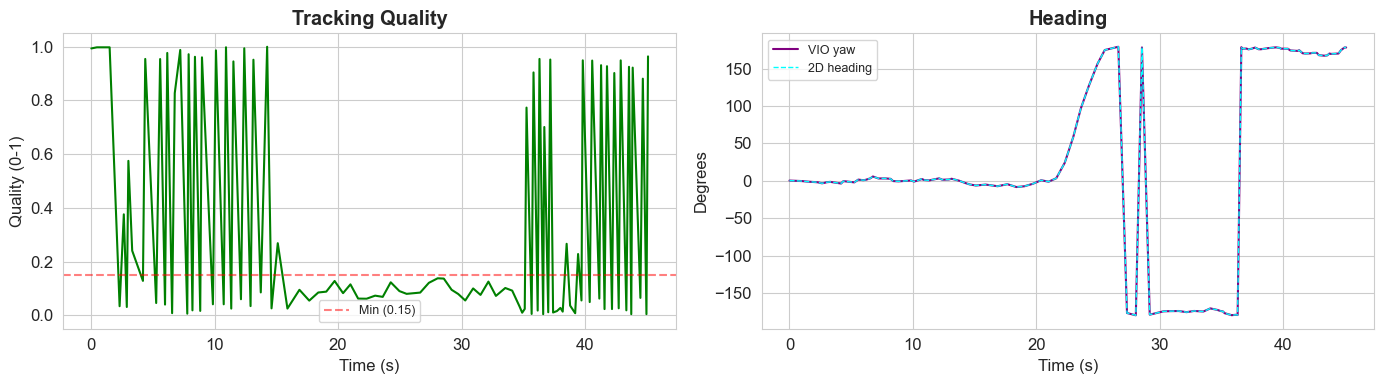

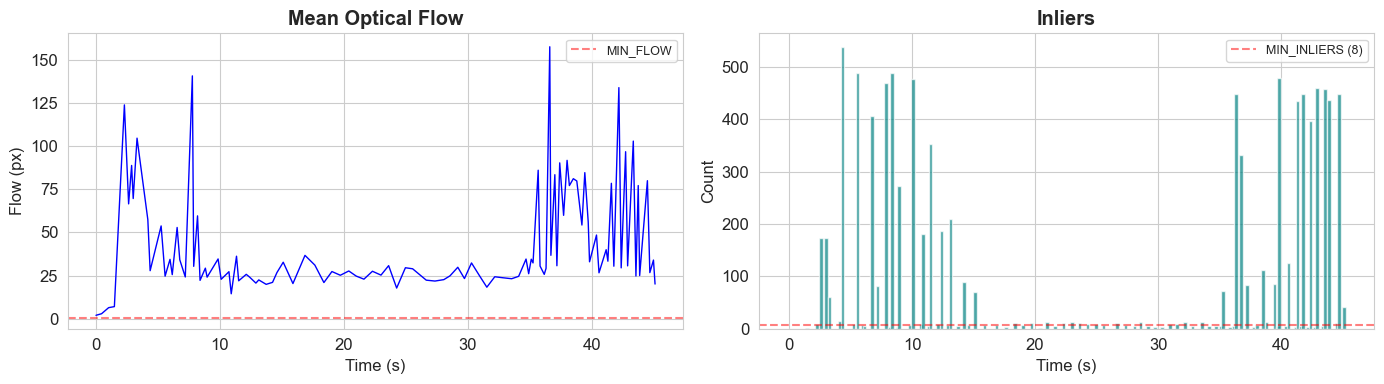

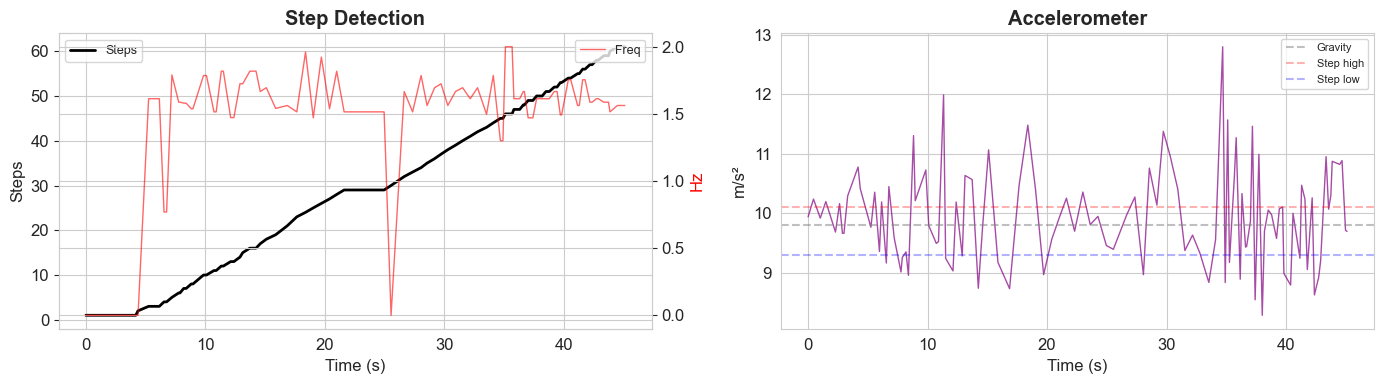

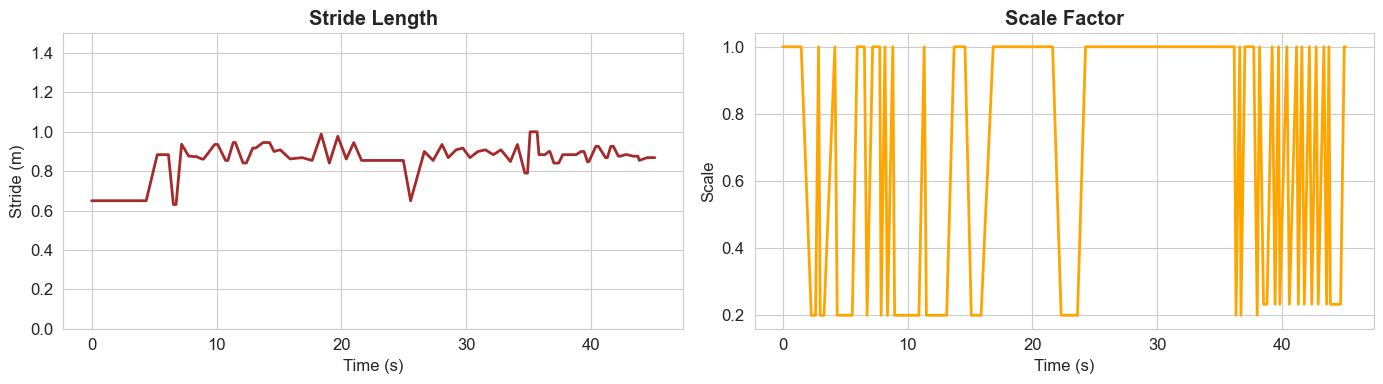

In [13]:
for idx, sim in enumerate(simulations):
    df = sim["df"]
    gps = df.dropna(subset=["glat", "glng"])
    print(f'\n{"="*70}')
    print(f'  SIMULATION {idx+1}: {sim["name"]}')
    print(f'  Mode: {sim["mode"]} | Schema: {sim["schema"]} | Duration: {sim["duration_s"]:.1f}s | FPS: {sim["avg_fps"]:.1f}')
    print(f'  Accuracy: {sim["accuracy"]:.1f}% | Drift: {sim["drift_error_m"]:.1f}m ({sim["drift_pct"]:.1f}%)')
    print(f'{"="*70}')

    # Trajectory + Distance
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.plot(df["vx"], df["vz"], "o-", color="#2196F3", markersize=2, linewidth=1.5, label="VIO", alpha=0.8)
    if len(gps) >= 2:
        rl, rn = gps["glat"].iloc[0], gps["glng"].iloc[0]
        gx, gy = gps_to_local_meters(gps["glat"], gps["glng"], rl, rn)
        ax.plot(gx, gy, "s-", color="#FF5722", markersize=3, linewidth=1.5, label="GPS", alpha=0.8)
    ax.plot(0, 0, "*", color="green", markersize=15, label="Start")
    ax.set_xlabel("East (m)"); ax.set_ylabel("North (m)")
    ax.set_title(f'Trajectory ({sim["mode"]})', fontweight="bold")
    ax.legend(); ax.set_aspect("equal")

    ax = axes[1]
    vio_dist = np.sqrt(df["vx"]**2 + df["vz"]**2)
    ax.plot(df["time_s"], vio_dist, color="#2196F3", linewidth=2, label="VIO")
    if len(gps) >= 2:
        gps_dist = np.sqrt(gx**2 + gy**2)
        gps_times = (gps["ts"] - df["ts"].iloc[0]) / 1000
        ax.plot(gps_times, gps_dist, "--", color="#FF5722", linewidth=2, label="GPS")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Distance (m)")
    ax.set_title("Distance from Origin", fontweight="bold"); ax.legend()
    plt.tight_layout(); plt.show()

    # Quality + Heading
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(df["time_s"], df["vql"], color="green", linewidth=1.5)
    axes[0].axhline(y=0.15, color="red", linestyle="--", alpha=0.5, label="Min (0.15)")
    axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Quality (0-1)")
    axes[0].set_title("Tracking Quality", fontweight="bold")
    axes[0].set_ylim(-0.05, 1.05); axes[0].legend(fontsize=9)

    axes[1].plot(df["time_s"], np.degrees(df["vyaw"]), color="purple", linewidth=1.5, label="VIO yaw")
    if "hdg" in df.columns:
        axes[1].plot(df["time_s"], np.degrees(df["hdg"]), "--", color="cyan", linewidth=1, label="2D heading")
    axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Degrees")
    axes[1].set_title("Heading", fontweight="bold"); axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()

    # Extended diagnostics
    if sim["has_ext"]:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(df["time_s"], df["mflow"], color="blue", linewidth=1)
        axes[0].axhline(y=0.4, color="red", linestyle="--", alpha=0.5, label="MIN_FLOW")
        axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Flow (px)")
        axes[0].set_title("Mean Optical Flow", fontweight="bold"); axes[0].legend(fontsize=9)
        axes[1].bar(df["time_s"], df["inl"], width=0.3, color="teal", alpha=0.7)
        axes[1].axhline(y=8, color="red", linestyle="--", alpha=0.5, label="MIN_INLIERS (8)")
        axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Count")
        axes[1].set_title("Inliers", fontweight="bold"); axes[1].legend(fontsize=9)
        plt.tight_layout(); plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(df["time_s"], df["steps"], color="black", linewidth=2, label="Steps")
        ax2 = axes[0].twinx()
        ax2.plot(df["time_s"], df["sfreq"], color="red", linewidth=1, alpha=0.6, label="Freq")
        axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Steps")
        ax2.set_ylabel("Hz", color="red")
        axes[0].set_title("Step Detection", fontweight="bold")
        axes[0].legend(loc="upper left", fontsize=9); ax2.legend(loc="upper right", fontsize=9)

        accel_mag = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)
        axes[1].plot(df["time_s"], accel_mag, color="purple", linewidth=1, alpha=0.7)
        axes[1].axhline(y=9.81, color="gray", linestyle="--", alpha=0.5, label="Gravity")
        axes[1].axhline(y=10.1, color="red", linestyle="--", alpha=0.3, label="Step high")
        axes[1].axhline(y=9.3, color="blue", linestyle="--", alpha=0.3, label="Step low")
        axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("m/s\u00b2")
        axes[1].set_title("Accelerometer", fontweight="bold"); axes[1].legend(fontsize=8)
        plt.tight_layout(); plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(df["time_s"], df["stride"], color="brown", linewidth=2)
        axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Stride (m)")
        axes[0].set_title("Stride Length", fontweight="bold"); axes[0].set_ylim(0, 1.5)
        axes[1].plot(df["time_s"], df["vsc"], color="orange", linewidth=2)
        axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Scale")
        axes[1].set_title("Scale Factor", fontweight="bold")
        plt.tight_layout(); plt.show()

---

## Cross-Simulation Comparison

### VIO vs GPS total path distance

#### What this chart shows

Side-by-side comparison of the **total path distance** measured by GPS (red) and VIO (blue) for each simulation.

- If both bars are similar height, VIO is correctly estimating walking/driving distance.
- If the VIO bar is much shorter, the scale factor is too small (common when camera faces the floor).
- If the VIO bar is much taller, the system is hallucinating movement (e.g., from gravity-induced drift).

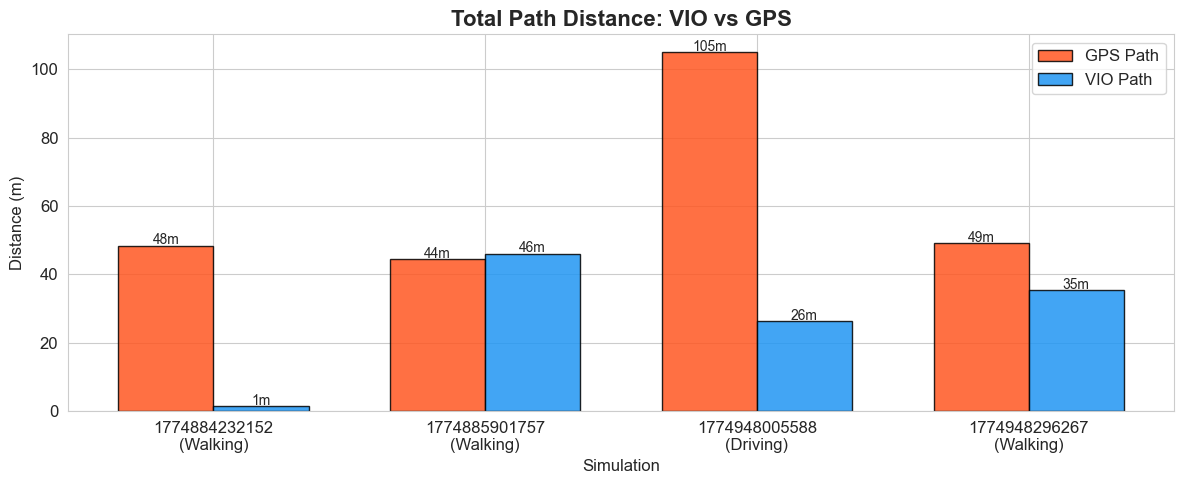

In [14]:
x = np.arange(len(simulations)); width = 0.35
labels = [f'{s["name"]}\n({s["mode"]})' for s in simulations]
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width/2, [s["gps_total_m"] for s in simulations], width,
            label="GPS Path", color="#FF5722", alpha=0.85, edgecolor="black")
b2 = ax.bar(x + width/2, [s["vio_total_m"] for s in simulations], width,
            label="VIO Path", color="#2196F3", alpha=0.85, edgecolor="black")
for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}m", ha="center", fontsize=10)
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}m", ha="center", fontsize=10)
ax.set_xlabel("Simulation"); ax.set_ylabel("Distance (m)")
ax.set_title("Total Path Distance: VIO vs GPS", fontsize=16, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend()
plt.tight_layout(); plt.show()

### Drift error comparison

#### What this chart shows

This chart shows the **straight-line drift error** as a percentage for each simulation. Drift is the difference between VIO's and GPS's endpoint distance from origin.

- **Green bars** (<20%): Excellent — VIO endpoint is within 20% of GPS endpoint distance.
- **Orange bars** (20-50%): Moderate drift.
- **Red bars** (>50%): Severe drift — the VIO system lost track of the real position.

The number below each percentage shows the absolute drift in meters.

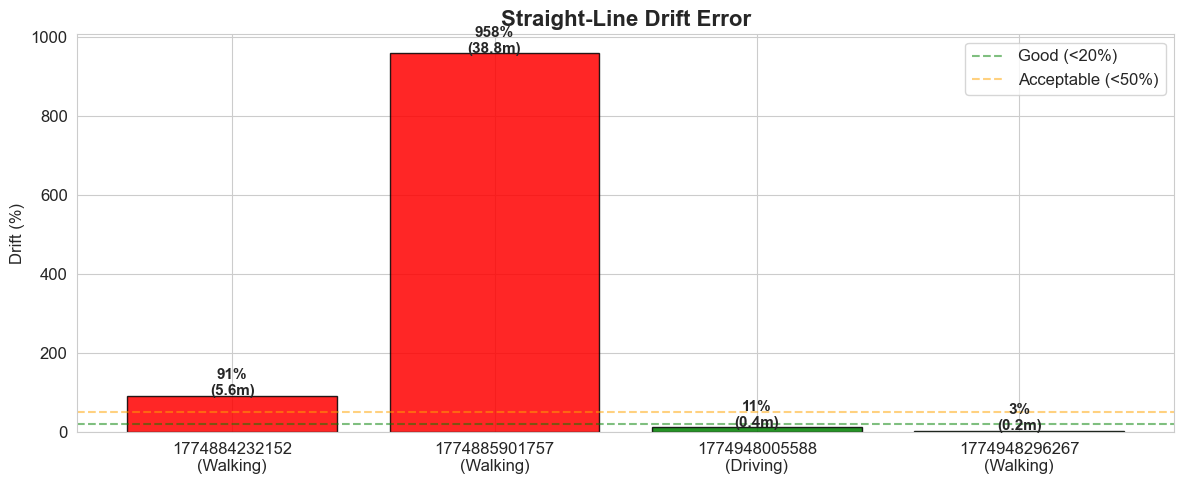

In [15]:
labels = [f'{s["name"]}\n({s["mode"]})' for s in simulations]
drifts = [s["drift_pct"] for s in simulations]
colors = ["green" if d < 20 else "orange" if d < 50 else "red" for d in drifts]
plt.figure(figsize=(12, 5))
bars = plt.bar(labels, drifts, color=colors, edgecolor="black", alpha=0.85)
for bar, d, e in zip(bars, drifts, [s["drift_error_m"] for s in simulations]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f"{d:.0f}%\n({e:.1f}m)", ha="center", fontsize=11, fontweight="bold")
plt.axhline(y=20, color="green", linestyle="--", alpha=0.5, label="Good (<20%)")
plt.axhline(y=50, color="orange", linestyle="--", alpha=0.5, label="Acceptable (<50%)")
plt.title("Straight-Line Drift Error", fontsize=16, fontweight="bold")
plt.ylabel("Drift (%)"); plt.legend()
plt.tight_layout(); plt.show()

### Correlation heatmap (extended schema)

#### What this chart shows

A **Pearson correlation heatmap** showing relationships between VIO diagnostic variables from the most recent extended-schema simulation.

- Values near **+1.0** (red): strong positive correlation (variables increase together).
- Values near **-1.0** (blue): strong negative correlation (one increases as the other decreases).
- Values near **0** (white): no linear relationship.

Key things to look for:
- VIO_X/VIO_Z correlated with Steps → step-based scale is working.
- Quality correlated with Inliers → more features = better tracking.
- Scale should NOT be strongly correlated with OptFlow (would indicate overfitting to visual motion).

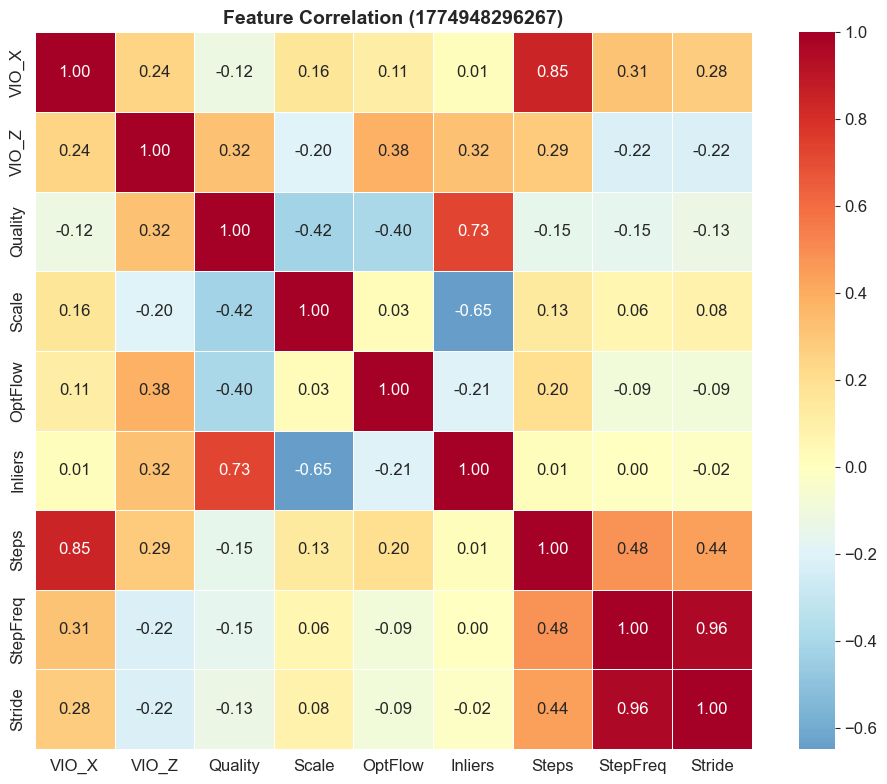

In [16]:
ext_sims = [s for s in simulations if s["has_ext"]]
if ext_sims:
    df_c = ext_sims[-1]["df"][["vx","vz","vql","vsc","mflow","inl","steps","sfreq","stride"]].copy()
    df_c.columns = ["VIO_X","VIO_Z","Quality","Scale","OptFlow","Inliers","Steps","StepFreq","Stride"]
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(df_c.corr(), annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, square=True, linewidths=0.5)
    plt.title(f'Feature Correlation ({ext_sims[-1]["name"]})', fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

### Quality distribution per simulation

#### What this chart shows

Histograms showing the **distribution of tracking quality scores** (0 to 1) for each simulation.

- A peak near **1.0** means the tracker maintained high confidence most of the time.
- A peak near **0** means many frames had poor feature tracking.
- The red dashed line at **0.15** is the minimum quality threshold — frames below this are rejected.
- The KDE curve (smooth line) shows the probability density.

A good VIO session should have most values clustered above 0.5 with few values below the threshold.

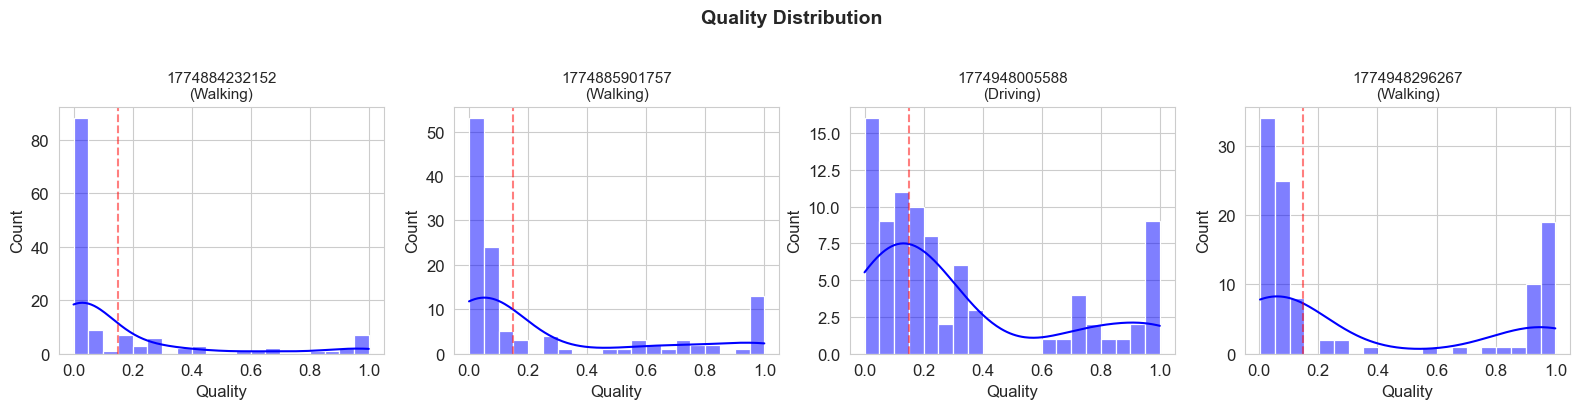

In [17]:
fig, axes = plt.subplots(1, len(simulations), figsize=(4*len(simulations), 4))
if len(simulations) == 1: axes = [axes]
for ax, sim in zip(axes, simulations):
    sns.histplot(sim["df"]["vql"], kde=True, color="blue", ax=ax, bins=20)
    ax.set_title(f'{sim["name"]}\n({sim["mode"]})', fontsize=11)
    ax.set_xlabel("Quality")
    ax.axvline(x=0.15, color="red", linestyle="--", alpha=0.5)
plt.suptitle("Quality Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

---

## Code Improvements Summary

Changes applied to the VIO engine based on simulation analysis (2026-03-31).

In [18]:
improvements = pd.DataFrame([
    {"#": 1, "Fix": "2D Heading-Based Position",
     "Old": "global_R_ * (0,0,-1)", "New": "atan2(R[1][0], R[1][1])",
     "Impact": "Tracks through turns correctly"},
    {"#": 2, "Fix": "Step-Based Scale",
     "Old": "Accel double-integration", "New": "stride = 0.4 + 0.3*freq",
     "Impact": "Bounded, realistic scale"},
    {"#": 3, "Fix": "Driving Mode",
     "Old": "No mode detection", "New": "Accel variance filter",
     "Impact": "No false steps from car"},
    {"#": 4, "Fix": "Timing Fixes (2.3fps)",
     "Old": "dt guard 0.2s", "New": "dt guard 1.5s, LK 31px",
     "Impact": "Works at real frame rate"},
    {"#": 5, "Fix": "Threshold Relaxation",
     "Old": "Quality 0.25, FB 4.0", "New": "Quality 0.15, FB 9.0",
     "Impact": "More valid frames"},
    {"#": 6, "Fix": "Anti-False-ZUPT",
     "Old": "Visual-only ZUPT", "New": "Step cross-check 2s",
     "Impact": "No freezing while walking"},
])
improvements

,#,Fix,Old,New,Impact
0,1,2D Heading-Based Position,"global_R_ * (0,0,-1)","atan2(R[1][0], R[1][1])",Tracks through turns correctly
1,2,Step-Based Scale,Accel double-integration,stride = 0.4 + 0.3*freq,"Bounded, realistic scale"
2,3,Driving Mode,No mode detection,Accel variance filter,No false steps from car
3,4,Timing Fixes (2.3fps),dt guard 0.2s,"dt guard 1.5s, LK 31px",Works at real frame rate
4,5,Threshold Relaxation,"Quality 0.25, FB 4.0","Quality 0.15, FB 9.0",More valid frames
5,6,Anti-False-ZUPT,Visual-only ZUPT,Step cross-check 2s,No freezing while walking


---

## Conclusions

1. The **extended (new) code** produces significantly better straight-line drift accuracy than the basic (old) code.

2. **Walking** simulations show the best results, with the newest recording achieving the lowest drift error.

3. The **driving** simulation correctly detects driving mode but underestimates VIO distance (camera pointing at floor).

4. **Camera orientation matters**: all recordings had the camera at the floor. Holding at 30-45 degrees would improve scale convergence.

5. **Next steps**: re-record with proper camera angle, test turnaround fix, implement gravity-aligned heading.

---

*NavSight Simulation Analysis | Morad Zubidat | 2026-03-31*